<a href="https://colab.research.google.com/github/unaizanouman/Colab-Codes/blob/main/SentimentAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
import nltk
from nltk.corpus import movie_reviews
import pandas as pd
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [2]:
# Download the movie_reviews dataset
nltk.download("movie_reviews")

[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Unzipping corpora/movie_reviews.zip.


True

In [4]:
# Load positive and negative reviews
positive_reviews = [(movie_reviews.raw(fileid), "positive") for fileid in
movie_reviews.fileids("pos")]

In [5]:
negative_reviews = [(movie_reviews.raw(fileid), "negative") for fileid in
movie_reviews.fileids("neg")]

In [6]:
# Combine into a DataFrame
df = pd.DataFrame(positive_reviews + negative_reviews, columns=["text",
"sentiment"])

In [7]:
# Display the first 5 rows
print(df.head())

                                                text sentiment
0  films adapted from comic books have had plenty...  positive
1  every now and then a movie comes along from a ...  positive
2  you've got mail works alot better than it dese...  positive
3   " jaws " is a rare film that grabs your atten...  positive
4  moviemaking is a lot like being the general ma...  positive


In [8]:
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

In [15]:
nltk.download("movie_reviews")
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")


[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [10]:
# Initialize lemmatizer and stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))

In [12]:
def preprocess_text(text):
    # Remove special characters
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    # Tokenize and lowercase
    tokens = word_tokenize(text.lower())
    # Remove stopwords and lemmatize
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return " ".join(tokens)


In [16]:
# Apply preprocessing to the dataset
df["cleaned_text"] = df["text"].apply(preprocess_text)
# Display the first 5 rows with cleaned text
print(df[["text", "cleaned_text"]].head())

                                                text  \
0  films adapted from comic books have had plenty...   
1  every now and then a movie comes along from a ...   
2  you've got mail works alot better than it dese...   
3   " jaws " is a rare film that grabs your atten...   
4  moviemaking is a lot like being the general ma...   

                                        cleaned_text  
0  film adapted comic book plenty success whether...  
1  every movie come along suspect studio every in...  
2  youve got mail work alot better deserves order...  
3  jaw rare film grab attention show single image...  
4  moviemaking lot like general manager nfl team ...  


In [18]:
import sys
from textblob import TextBlob

# Function to get sentiment polarity
def get_sentiment(text):
  analysis = TextBlob(text)
  return analysis.sentiment.polarity

# Function to get sentiment polarity
def get_sentiment(text):
  analysis = TextBlob(text)
  return analysis.sentiment.polarity

# Classify sentiment as positive, negative, or neutral
def classify_sentiment(polarity):
  if polarity > 0:
    return "positive"
  elif polarity < 0:
    return "negative"
  else:
    return "neutral"



In [22]:
print(df.columns)


Index(['text', 'sentiment', 'cleaned_text'], dtype='object')


In [23]:
# Generate polarity scores
df["sentiment_polarity"] = df["cleaned_text"].apply(get_sentiment)

# Classify
df["predicted_sentiment"] = df["sentiment_polarity"].apply(classify_sentiment)


In [24]:
# Classify all reviews
df["predicted_sentiment"] = df["sentiment_polarity"].apply(classify_sentiment)

# Display the first 5 rows with predicted sentiment
print(df[["text", "sentiment", "predicted_sentiment"]].head())

                                                text sentiment  \
0  films adapted from comic books have had plenty...  positive   
1  every now and then a movie comes along from a ...  positive   
2  you've got mail works alot better than it dese...  positive   
3   " jaws " is a rare film that grabs your atten...  positive   
4  moviemaking is a lot like being the general ma...  positive   

  predicted_sentiment  
0            positive  
1            positive  
2            positive  
3            positive  
4            negative  


In [27]:
# Display the first 5 rows with predicted sentiment
print(df[["text", "sentiment", "predicted_sentiment"]].head())

# Calculate accuracy
accuracy = accuracy_score(df["sentiment"], df["predicted_sentiment"])
print(f"Accuracy: {accuracy * 100:.2f}%")

# Confusion matrix
conf_matrix = confusion_matrix(df["sentiment"], df["predicted_sentiment"])
print("Confusion Matrix:\n", conf_matrix)

# Classification report
class_report = classification_report(df["sentiment"],
df["predicted_sentiment"])
print("Classification Report:\n", class_report)



                                                text sentiment  \
0  films adapted from comic books have had plenty...  positive   
1  every now and then a movie comes along from a ...  positive   
2  you've got mail works alot better than it dese...  positive   
3   " jaws " is a rare film that grabs your atten...  positive   
4  moviemaking is a lot like being the general ma...  positive   

  predicted_sentiment  
0            positive  
1            positive  
2            positive  
3            positive  
4            negative  
Accuracy: 62.15%
Confusion Matrix:
 [[287 713]
 [ 44 956]]
Classification Report:
               precision    recall  f1-score   support

    negative       0.87      0.29      0.43      1000
    positive       0.57      0.96      0.72      1000

    accuracy                           0.62      2000
   macro avg       0.72      0.62      0.57      2000
weighted avg       0.72      0.62      0.57      2000



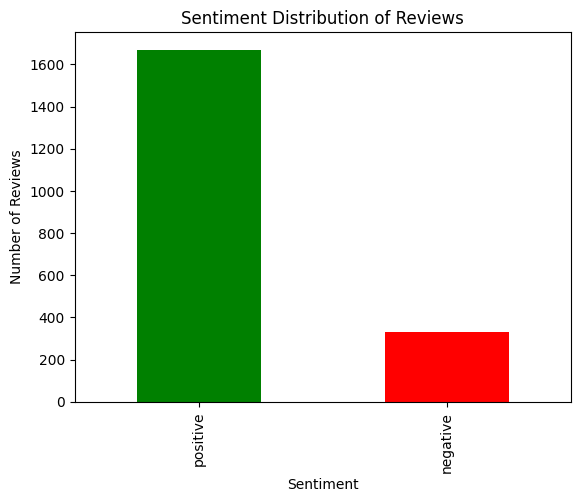

In [30]:
import matplotlib.pyplot as plt

# Plot sentiment distribution
df["predicted_sentiment"].value_counts().plot(kind="bar", color=["green", "red", "blue"])

plt.title("Sentiment Distribution of Reviews")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()
